# 1. INTRO: Bias vs Variance


## 1.1 Qué es un árbol de decisión?
Un tipo de algoritmo de aprendizaje supervisado que se basa en realizar particiones a partir de distintos niveles de las variables disponibles.

## 1.2 Import
Importamos todas las librerías necesarias para este análisis: pandas, numpy, seaborn, matplotlib.

In [ ]:
!pip install graphviz

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, root_mean_squared_error

# Trade-off BIAS vs Variance

## 1.3 Carga el dataset de coches de segunda mano
Para probar a hacer árboles de decisión sin overfitting utilizaremos un dataset sobre el **precio** de distintos **coches de segunda mano** que se encuentra en Kaggle ([aquí](https://www.kaggle.com/harturo123/online-adds-of-used-cars)).

Podéis encontrar el archivo listo para importar en github: https://github.com/JimenaAreta/thevalley-MDS/blob/jimena/datasets/coches_usados_esp.csv.

Importa este dataset en un dataframe llamado **df**.

In [ ]:
# Url archivo raw
url = "https://raw.githubusercontent.com/JimenaAreta/thevalley-MDS/refs/heads/jimena/datasets/coches_usados_esp-2.csv"
# Importa csv
df = pd.read_csv(url, sep=';')

# Visualización primeras filas
df.head()

,ID,make,model,version,months_old,power,sale_type,num_owners,gear_type,fuel_type,kms,price
0,97860,Porsche,911,Carrera 4 S Coup�,240.0,210.0,classic,3.0,manual,gasoline,202000.0,999999
1,27821,Ford,Mustang,Gt500 Cabrio Vendido,54.0,487.0,used,1.0,manual,gasoline,30000.0,685000
2,97801,Porsche,911,3.3 Turbo Targa (Precio A Consultar),358.0,220.0,used,NaN,manual,gasoline,56300.0,555555
3,98251,Porsche,911,R Unidad 343 De 991-Iva Deducible,14.0,368.0,used,1.0,manual,gasoline,2800.0,470000
4,98250,Porsche,911,Gt2 Rs,3.0,515.0,used,NaN,NaN,gasoline,10.0,450000


# 2. EDA
Realizaremos un pequeño análisis exploratorio visual para familiarizarnos con el dataset.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93991 entries, 0 to 93990
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          93991 non-null  int64  
 1   make        93991 non-null  object 
 2   model       93991 non-null  object 
 3   version     93991 non-null  object 
 4   months_old  93717 non-null  float64
 5   power       93504 non-null  float64
 6   sale_type   93979 non-null  object 
 7   num_owners  22660 non-null  float64
 8   gear_type   92710 non-null  object 
 9   fuel_type   93926 non-null  object 
 10  kms         93127 non-null  float64
 11  price       93991 non-null  int64  
dtypes: float64(4), int64(2), object(6)
memory usage: 8.6+ MB


In [ ]:
df.count()

,0
ID,93991
make,93991
model,93991
version,93991
months_old,93717
power,93504
sale_type,93979
num_owners,22660
gear_type,92710
fuel_type,93926


In [ ]:
df.isna().sum()
#num_owners tiene muchos nulos

,0
ID,0
make,0
model,0
version,0
months_old,274
power,487
sale_type,12
num_owners,71331
gear_type,1281
fuel_type,65


In [ ]:
df.describe()

,ID,months_old,power,num_owners,kms,price
count,93991.00000,93717.000000,93504.000000,22660.000000,93127.000000,93991.000000
mean,55100.87935,63.094775,99.729477,1.055119,82702.565250,16587.291379
std,33119.32602,56.837686,42.698809,0.277124,75186.697789,15563.712383
min,25.00000,1.000000,0.000000,1.000000,0.000000,200.000000
25%,25452.50000,16.000000,77.000000,1.000000,18300.000000,8500.000000
50%,53896.00000,46.000000,88.000000,1.000000,66000.000000,13490.000000
75%,83573.50000,96.000000,110.000000,1.000000,129000.000000,19999.000000
max,113143.00000,374.000000,809.000000,11.000000,497000.000000,999999.000000


# 3. EJEMPLO Sin OverFitting
Vamos a ver paso a paso cómo realizar un modelo que prediga el precio sin caer en overfitting.

## 3.1 Preparamos los datos
El dataframe tiene algunos nulos, así como variables categóricas y presencia de ciertas variables que probablemente no queramos usar.

### 3.1.1 Variables Útiles
De entre las variables disponibles, veamos cuáles queremos utilizar como predictoras para el estudio.

In [ ]:
df.head()

,ID,make,model,version,months_old,power,sale_type,num_owners,gear_type,fuel_type,kms,price
0,97860,Porsche,911,Carrera 4 S Coup�,240.0,210.0,classic,3.0,manual,gasoline,202000.0,999999
1,27821,Ford,Mustang,Gt500 Cabrio Vendido,54.0,487.0,used,1.0,manual,gasoline,30000.0,685000
2,97801,Porsche,911,3.3 Turbo Targa (Precio A Consultar),358.0,220.0,used,NaN,manual,gasoline,56300.0,555555
3,98251,Porsche,911,R Unidad 343 De 991-Iva Deducible,14.0,368.0,used,1.0,manual,gasoline,2800.0,470000
4,98250,Porsche,911,Gt2 Rs,3.0,515.0,used,NaN,NaN,gasoline,10.0,450000


In [ ]:
df.columns

Index(['ID', 'make', 'model', 'version', 'months_old', 'power', 'sale_type',
       'num_owners', 'gear_type', 'fuel_type', 'kms', 'price'],
      dtype='object')

In [ ]:
# se quita ID y version
cols = [
    "make",
    "model",
    "months_old",
    "power",
    "sale_type",
    "num_owners",
    "gear_type",
    "fuel_type",
    "kms",
    "price",
]

### 3.1.2 Dumificación de variables categóricas

In [ ]:
df_i = pd.get_dummies(
    df[cols],
    prefix_sep="_",
    drop_first=True,
    columns=["make", "model", "sale_type", "gear_type", "fuel_type"],
    dtype=int
)

display(len(df_i))
df_i.head()

93991

,months_old,power,num_owners,kms,price,make_Audi,make_Bentley,make_Bmw,make_Chevrolet,make_Chrysler,...,sale_type_new,sale_type_used,gear_type_manual,gear_type_semi-automatic,fuel_type_LPG,fuel_type_diesel,fuel_type_electric,fuel_type_etanol,fuel_type_gasoline,fuel_type_hybrid
0,240.0,210.0,3.0,202000.0,999999,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
1,54.0,487.0,1.0,30000.0,685000,0,0,0,0,0,...,0,1,1,0,0,0,0,0,1,0
2,358.0,220.0,NaN,56300.0,555555,0,0,0,0,0,...,0,1,1,0,0,0,0,0,1,0
3,14.0,368.0,1.0,2800.0,470000,0,0,0,0,0,...,0,1,1,0,0,0,0,0,1,0
4,3.0,515.0,NaN,10.0,450000,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0


In [ ]:
print(df_i.columns)

# QUESTION
# ¿ Cómo ver todas las columnas creadas?

Index(['months_old', 'power', 'num_owners', 'kms', 'price', 'make_Audi',
       'make_Bentley', 'make_Bmw', 'make_Chevrolet', 'make_Chrysler',
       ...
       'sale_type_new', 'sale_type_used', 'gear_type_manual',
       'gear_type_semi-automatic', 'fuel_type_LPG', 'fuel_type_diesel',
       'fuel_type_electric', 'fuel_type_etanol', 'fuel_type_gasoline',
       'fuel_type_hybrid'],
      dtype='object', length=299)


In [ ]:
type(df_i.columns)

pandas.core.indexes.base.Index

In [ ]:
print(list(df_i.columns))

['months_old', 'power', 'num_owners', 'kms', 'price', 'make_Audi', 'make_Bentley', 'make_Bmw', 'make_Chevrolet', 'make_Chrysler', 'make_Citroen', 'make_Dacia', 'make_Ds', 'make_Fiat', 'make_Ford', 'make_Honda', 'make_Hyundai', 'make_Iveco', 'make_Jaguar', 'make_Jeep', 'make_Kia', 'make_Land', 'make_Mazda', 'make_Mercedes-Benz', 'make_Mini', 'make_Mitsubishi', 'make_Nissan', 'make_Opel', 'make_Peugeot', 'make_Porsche', 'make_Renault', 'make_Saab', 'make_Seat', 'make_Skoda', 'make_Smart', 'make_Ssangyong', 'make_Suzuki', 'make_Toyota', 'make_Volkswagen', 'make_Volvo', 'model_118', 'model_120', 'model_2008', 'model_206', 'model_207', 'model_208', 'model_216', 'model_218', 'model_220', 'model_3', 'model_3008', 'model_307', 'model_308', 'model_316', 'model_318', 'model_320', 'model_325', 'model_330', 'model_407', 'model_420', 'model_500', 'model_5008', 'model_500C', 'model_500L', 'model_500X', 'model_508', 'model_520', 'model_525', 'model_530', 'model_6', 'model_640', 'model_730', 'model_9-

### 3.1.3 Limpieza de nulos
Con la dumificación hemos eliminado los nulos en las columnas categóricas sin deshacernos de las filas. Queda algún nulo en las variables numéricas?


In [ ]:
# Solo mostrar la columnas con null.
# df_i[["months_old", "power", "num_owners", "kms", "price"]].isna().sum()
null_counts = df_i.isnull().sum()
columns_with_nulls = null_counts[null_counts > 0]
print(columns_with_nulls)

months_old      274
power           487
num_owners    71331
kms             864
dtype: int64


In [ ]:
df_i["num_owners"].value_counts()

,count
num_owners,
1.0,21553
2.0,1025
3.0,58
5.0,14
4.0,4
6.0,3
11.0,1
7.0,1
10.0,1


In [ ]:
# Hay muchos nulos en num_owners
# Quizás esto tiene que ver con origenes del coche desconocidos?
# Vamos a limpiar la variable en 1, 2, 3+, nulo y la utilizamos como categórica
filtro_muchos_owners = df_i["num_owners"] >= 3
df_i.loc[filtro_muchos_owners, "num_owners"] = "3+"
df_i = pd.get_dummies(
    df_i, prefix_sep="_", dummy_na=True, columns=["num_owners"], dtype=int
)
df_i.head()

/tmp/ipython-input-1619561189.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3+' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_i.loc[filtro_muchos_owners, "num_owners"] = "3+"


,months_old,power,kms,price,make_Audi,make_Bentley,make_Bmw,make_Chevrolet,make_Chrysler,make_Citroen,...,fuel_type_LPG,fuel_type_diesel,fuel_type_electric,fuel_type_etanol,fuel_type_gasoline,fuel_type_hybrid,num_owners_1.0,num_owners_2.0,num_owners_3+,num_owners_nan
0,240.0,210.0,202000.0,999999,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,54.0,487.0,30000.0,685000,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
2,358.0,220.0,56300.0,555555,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,14.0,368.0,2800.0,470000,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
4,3.0,515.0,10.0,450000,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [ ]:
df_i[["months_old", "power", "kms", "price"]].isna().sum()

,0
months_old,274
power,487
kms,864
price,0


In [ ]:
# Para el resto de características se asgina el valor de su mediana.
for col in ["months_old", "power", "kms"]:
    df_i[col] = df_i[col].fillna(df_i[col].median())

In [ ]:
# Verificar que no quedan columnas con null.
# Solo mostrar la columnas con null.
null_counts = df_i.isnull().sum()
columns_with_nulls = null_counts[null_counts > 0]
print(len(columns_with_nulls))
print(columns_with_nulls)

0
Series([], dtype: int64)


## 3.2 Train - test split
Separamos el set de datos en dos utilizando [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).


In [ ]:
X = df_i.drop("price", axis=1)
y = df_i["price"]

len(X), len(y)

(93991, 93991)

In [ ]:
X.shape, y.shape

((93991, 301), (93991,))

In [ ]:
# train_test_split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## 3.3 Entrenamos el árbol de decisión
Sobre el set de entrenamiento, comprobamos el modelo sobre el set de test.
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html#sklearn.tree.DecisionTreeRegressor

In [ ]:
# Inicializo un árbol
modelo = tree.DecisionTreeRegressor(max_depth=10)
# Entreno el árbol con el set de entrenamiento
modelo.fit(X=X_train, y=y_train)
# Uso el árbol para predecir sobre el dataset de entrenamiento
y_pred_train = modelo.predict(X_train)
# Uso el árbol para predecir sobre el dataset de test
y_pred_test = modelo.predict(X_test)
# Cómo de buena es la predicción?
print(
    "RMSE en set de entrenamiento :",
    root_mean_squared_error(y_train, y_pred_train),
)
print("RMSE en set de test :", root_mean_squared_error(y_test, y_pred_test))

#la varianza es muy pequeña entre train y test

RMSE en set de entrenamiento : 4212.977503116961
RMSE en set de test : 5595.866619683489


In [ ]:
# Inicializo un árbol
modelo = tree.DecisionTreeRegressor(max_depth=5)
# Entreno el árbol con el set de entrenamiento
modelo.fit(X=X_train, y=y_train)
# Uso el árbol para predecir sobre el dataset de entrenamiento
y_pred_train = modelo.predict(X_train)
# Uso el árbol para predecir sobre el dataset de test
y_pred_test = modelo.predict(X_test)
# Cómo de buena es la predicción?
print(
    "RMSE en set de entrenamiento :",
    root_mean_squared_error(y_train, y_pred_train),
)
print("RMSE en set de test :", root_mean_squared_error(y_test, y_pred_test))

#cuando disminuimos la profundidad, se equivoca mas. mi modelo es mas sencillo porque le he bajado la profunidad, entonces no puede aprender mucho de los datos, lo hace peor.

RMSE en set de entrenamiento : 7140.0614444012435
RMSE en set de test : 7299.206539578955


In [ ]:
# Inicializo un árbol
modelo = tree.DecisionTreeRegressor(max_depth=50)
# Entreno el árbol con el set de entrenamiento
modelo.fit(X=X_train, y=y_train)
# Uso el árbol para predecir sobre el dataset de entrenamiento
y_pred_train = modelo.predict(X_train)
# Uso el árbol para predecir sobre el dataset de test
y_pred_test = modelo.predict(X_test)
# Cómo de buena es la predicción?
print(
    "RMSE en set de entrenamiento :",
    root_mean_squared_error(y_train, y_pred_train),
)
print("RMSE en set de test :", root_mean_squared_error(y_test, y_pred_test))

#esta super overfitting, se aprende tanto los datos que tiene poco error que luego con otros datos sube el error

RMSE en set de entrenamiento : 375.81868982483985
RMSE en set de test : 5740.929237969123


In [ ]:
# Funcion para entrenar el modelo por profundidades
def entrenar_modelo_y_predecir(modelo, max_depth):
    """
    Funcion para entrenar el modelo por profundidades
    modelo: modelo a entrenar
    max_depth: profundidad del árbol
    return: Serie con los resultados: [max_depth, rmse_train, rmse_test]
    """
    # Entreno el árbol con el set de entrenamiento
    modelo.fit(X=X_train, y=y_train)
    # Uso el árbol para predecir sobre el dataset de entrenamiento
    y_pred_train = modelo.predict(X_train)
    # Uso el árbol para predecir sobre el dataset de test
    y_pred_test = modelo.predict(X_test)
    # Cómo de buena es la predicción?
    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    #print("max_depth=", max_depth, " RMSE en set de entrenamiento :", rmse_train, )
    rmse_test = root_mean_squared_error(y_test, y_pred_test)
    #print("max_depth=", max_depth,  " RMSE en set de test          :", rmse_test  )

    data = [max_depth, rmse_train, rmse_test]
    cols=['max_depth', 'rmse_train', 'rmse_test']
    serie = pd.Series(data, index=cols)
    return serie

In [ ]:
def run_modelo_y_predecir(max_depth):
    modelo = tree.DecisionTreeRegressor(max_depth=max_depth)
    return entrenar_modelo_y_predecir(modelo, max_depth)


In [ ]:
print(run_modelo_y_predecir(max_depth=5))
print(run_modelo_y_predecir(max_depth=10))
print(run_modelo_y_predecir(max_depth=25))
print(run_modelo_y_predecir(max_depth=30))
print(run_modelo_y_predecir(max_depth=50))

max_depth        5.000000
rmse_train    7140.061444
rmse_test     7299.206540
dtype: float64
max_depth       10.000000
rmse_train    4212.977503
rmse_test     5591.101341
dtype: float64
max_depth       25.000000
rmse_train    1125.945738
rmse_test     5606.253199
dtype: float64
max_depth       30.000000
rmse_train     815.737134
rmse_test     5566.408369
dtype: float64
max_depth       50.000000
rmse_train     375.818690
rmse_test     5599.591663
dtype: float64


In [ ]:
def entrenar_lista_profundidades(lista):
  cols = ['max_depth', 'rmse_train', 'rmse_test']
  df = pd.DataFrame(columns=cols)

  for valor in lista:
    serie = run_modelo_y_predecir(max_depth=valor)
    #df = df.append(serie, ignore_index=True)
    # Agrega la nueva serie como última fila del DataFrame
    df.loc[len(df)] = serie

  return df

In [ ]:
lista = [5, 6, 7, 8, 9, 10, 11, 12, 15, 25, 30, 50]
df_rmse = entrenar_lista_profundidades(lista)
df_rmse

,max_depth,rmse_train,rmse_test
0,5.0,7140.061444,7299.206540
1,6.0,6438.043723,6654.274459
2,7.0,5865.840809,6247.466403
3,8.0,5200.132069,5964.373969
4,9.0,4665.861928,5784.789576
5,10.0,4212.977503,5610.333899
6,11.0,3797.484403,5572.469974
7,12.0,3454.069298,5627.363021
8,15.0,2629.149349,5772.435771
9,25.0,1125.940726,5609.047334


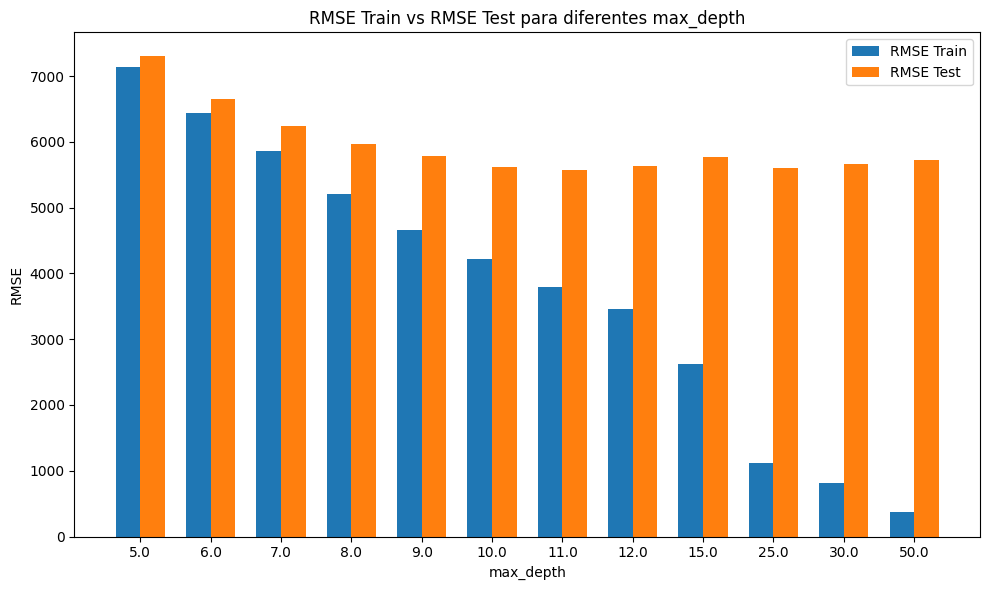

In [ ]:
# Extraer los datos relevantes para el gráfico
max_depth = df_rmse['max_depth']
rmse_train = df_rmse['rmse_train']
rmse_test = df_rmse['rmse_test']

# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Configurar las posiciones de las barras
bar_width = 0.35
index = range(len(max_depth))

# Grafico de barras
plt.bar(index, rmse_train, bar_width, label='RMSE Train')
plt.bar([i + bar_width for i in index], rmse_test, bar_width, label='RMSE Test')

# Configurar etiquetas y título
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.title('RMSE Train vs RMSE Test para diferentes max_depth')
plt.xticks([i + bar_width / 2 for i in index], max_depth)
plt.legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()

## 3.4 Probamos medidas contra el overfitting

### 3.4.1 min_samples_split
Tamaño muestral mínimo para permitir una partición.

In [ ]:
# Inicializo un árbol
max_depth = 11
modelo = tree.DecisionTreeRegressor(max_depth=max_depth, min_samples_split=20)
# Entrenamos y predecimos con dicho modelo
entrenar_modelo_y_predecir(modelo, max_depth=max_depth)

In [ ]:
# Inicializo un árbol
modelo = tree.DecisionTreeRegressor(max_depth=15, min_samples_split=20)
# Entrenamos y predecimos con dicho modelo
entrenar_modelo_y_predecir(modelo, max_depth=15)

In [ ]:
# Inicializo un árbol
modelo = tree.DecisionTreeRegressor(max_depth=15, min_samples_split=25)
# Entrenamos y predecimos con dicho modelo
entrenar_modelo_y_predecir(modelo, max_depth=15)

### 3.4.2 min_samples_leaf
Tamaño muestral mínimo en una hoja.

In [ ]:
# Inicializo un árbol
modelo = tree.DecisionTreeRegressor(
    max_depth=15, min_samples_split=25, min_samples_leaf=10
)
# Entrenamos y predecimos con dicho modelo
entrenar_modelo_y_predecir(modelo, max_depth=15)

In [ ]:
# Inicializo un árbol
modelo = tree.DecisionTreeRegressor(
    max_depth=20, min_samples_split=20, min_samples_leaf=2
)
# Entrenamos y predecimos con dicho modelo
entrenar_modelo_y_predecir(modelo, max_depth=20)

### 3.4.2 min_impurity_decrease
Mínimo descenso de impuridad.

Cantidad mínima de disminución de la impureza necesaria para realizar una división en un nodo. Este parámetro ayuda a prevenir el sobreajuste al asegurar que solo las divisiones que aportan una mejora significativa en la pureza del nodo sean consideradas.

In [ ]:
# Inicializo un árbol
modelo = tree.DecisionTreeRegressor(
    max_depth=15, min_samples_split=25, min_impurity_decrease=0.25
)
# Entrenamos y predecimos con dicho modelo
entrenar_modelo_y_predecir(modelo, max_depth=15)

# Entrenamiento fuerza bruta

In [ ]:
def entrenamiento_fuerza_bruta(lista_max_depth, lista_min_samples_split, lista_min_samples_leaf):
  cols = ['max_depth', 'min_samples_split', 'min_samples_leaf', 'rmse_train', 'rmse_test']
  df = pd.DataFrame(columns=cols)

  for v_max_depth in lista_max_depth:
    for v_min_samples_split in lista_min_samples_split:
      for v_min_samples_leaf in lista_min_samples_leaf:

        serie = run_modelo_y_predecir_v2(max_depth=v_max_depth, min_samples_split=v_min_samples_split, min_samples_leaf=v_min_samples_leaf)
        print(f'max_depth={v_max_depth}, min_samples_split={v_min_samples_split}, min_samples_leaf={v_min_samples_leaf} rmse_test={serie.iloc[2]}')
        df.loc[len(df)] = serie

  return df

In [ ]:
def run_modelo_y_predecir_v2(max_depth, min_samples_split, min_samples_leaf):
    modelo = tree.DecisionTreeRegressor(max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf)
    d = entrenar_modelo_y_predecir(modelo, max_depth)
    d['min_samples_split'] = min_samples_split
    d['min_samples_leaf'] = min_samples_leaf
    return d

In [ ]:
%%time
lista_max_depth = [7, 10, 11, 12, 25, 30, 50]
lista_min_samples_split = [2, 6, 8, 10, 15, 25, 30, 50]
lista_min_samples_leaf = [1, 2, 3, 7, 9, 11, 25]

df_rmse = entrenamiento_fuerza_bruta(lista_max_depth, lista_min_samples_split, lista_min_samples_leaf)

max_depth=7, min_samples_split=2, min_samples_leaf=1 rmse_test=6250.809439723047
max_depth=7, min_samples_split=2, min_samples_leaf=2 rmse_test=6785.4652964819015
max_depth=7, min_samples_split=2, min_samples_leaf=3 rmse_test=6927.53976163627
max_depth=7, min_samples_split=2, min_samples_leaf=7 rmse_test=6994.122426868833
max_depth=7, min_samples_split=2, min_samples_leaf=9 rmse_test=6880.512439869727
max_depth=7, min_samples_split=2, min_samples_leaf=11 rmse_test=6683.249973564455
max_depth=7, min_samples_split=2, min_samples_leaf=25 rmse_test=6451.170567022397
max_depth=7, min_samples_split=6, min_samples_leaf=1 rmse_test=6403.019169595915
max_depth=7, min_samples_split=6, min_samples_leaf=2 rmse_test=6929.961485152022
max_depth=7, min_samples_split=6, min_samples_leaf=3 rmse_test=6927.53976163627
max_depth=7, min_samples_split=6, min_samples_leaf=7 rmse_test=6994.122426868833
max_depth=7, min_samples_split=6, min_samples_leaf=9 rmse_test=6880.512439869727
max_depth=7, min_samples_sp

In [ ]:
# ordenar df_rmse por la columna rmse_test descendente
df_rmse = df_rmse.sort_values(by='rmse_test', ascending=True)
df_rmse.head(20)

,max_depth,min_samples_split,min_samples_leaf,rmse_train,rmse_test
378,50.0,30.0,1.0,5064.881289,5290.160566
322,30.0,30.0,1.0,5086.733305,5303.891002
308,30.0,15.0,1.0,4624.431572,5305.017355
364,50.0,15.0,1.0,4592.206202,5308.899695
266,25.0,30.0,1.0,5111.750072,5311.857657
252,25.0,15.0,1.0,4663.192140,5324.174592
371,50.0,25.0,1.0,4910.107241,5374.276315
315,30.0,25.0,1.0,4934.215347,5385.633622
301,30.0,10.0,1.0,4448.407809,5399.693379
357,50.0,10.0,1.0,4408.507686,5401.276120
